# Шаг 17. Первичный разведочный анализ

## Будет произведена проверка следующих показателей
1. **Частота категорий** (ABC-анализ) 
Будет выявлено:
- какие производители формируют ядро рынка (категория А);
- какие национальности наиболее массово представлены в миниатюрах, а какие являются нишевыми.
2. **Распределение наборов по историческим периодам**
Будет определено какие исторические периоды занимают большую часть рынка.
3. **Динамика по времени**
График по десятилетиям покажет пики в индустрии.
4. **Выбросы и аномалии**
С помощью Boxplot по num_figures будет определено:
- есть ли наборы с аномально большим количеством фигур;
- граница стандартного набора по числу фигур.
С помощью гистограмма aggregate_rating определим смещено ли распределение оценок обзоров.
5. **Связи между признаками**
С помощью графика среднего рейтинга по производителям будут определены приоритеты в производстве наборов.

=== 1. Распределение по производителям (Топ-10) ===


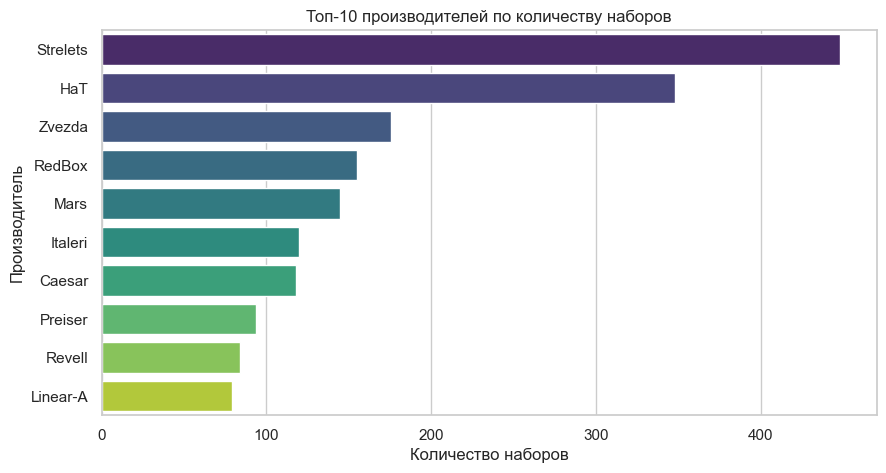


=== 2. Распределение по историческим периодам ===


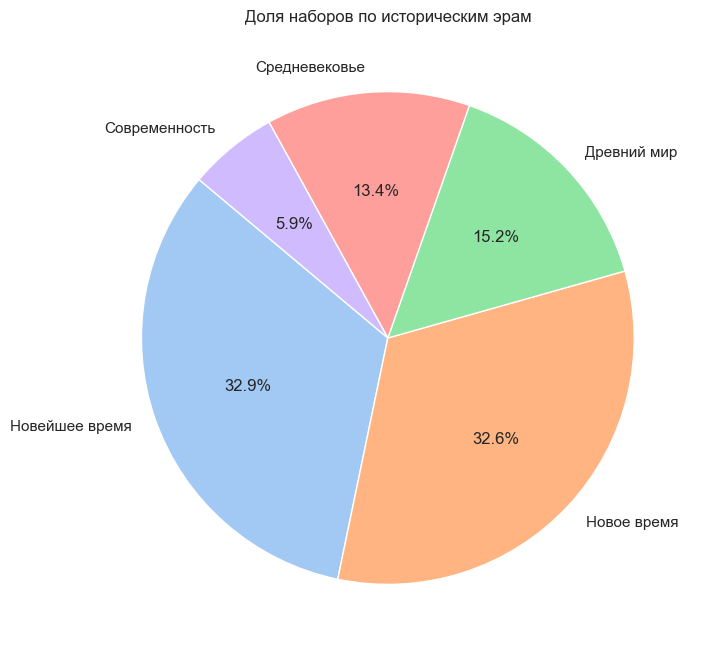


=== 3. Распределение по национальностям (Топ-15) ===
nationality
German       458
British      348
French       301
Russian      263
USA          262
Italian      257
Spanish       79
Japanese      68
Turkish       62
Austrian      62
Greek         59
Polish        55
Ukrainian     33
Swedish       31
Persian       29
Name: count, dtype: int64


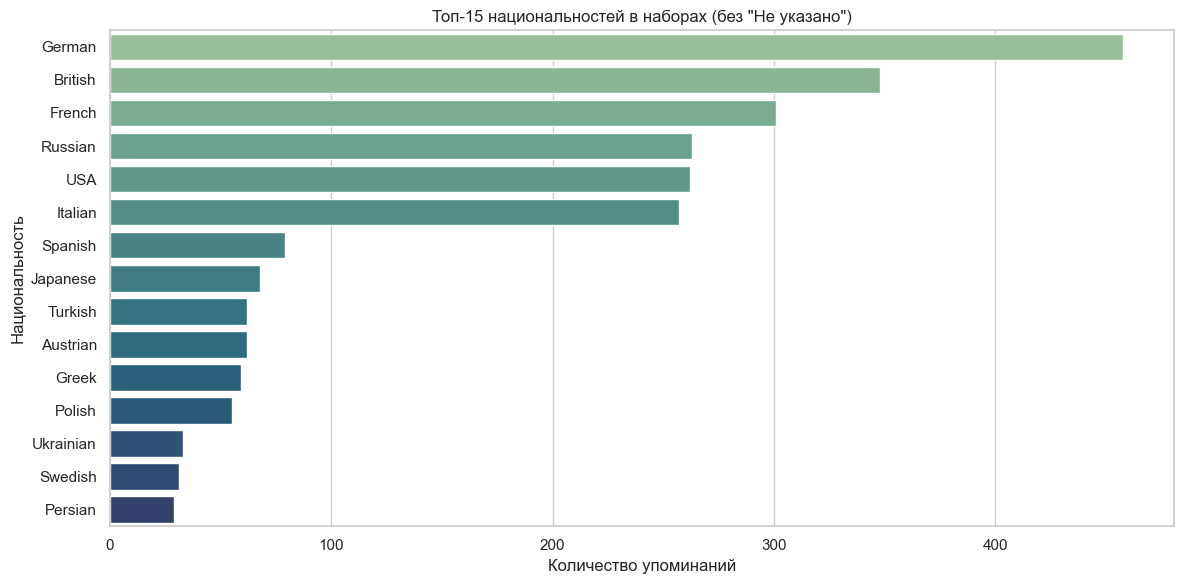


=== 4. Динамика выпусков по десятилетиям ===


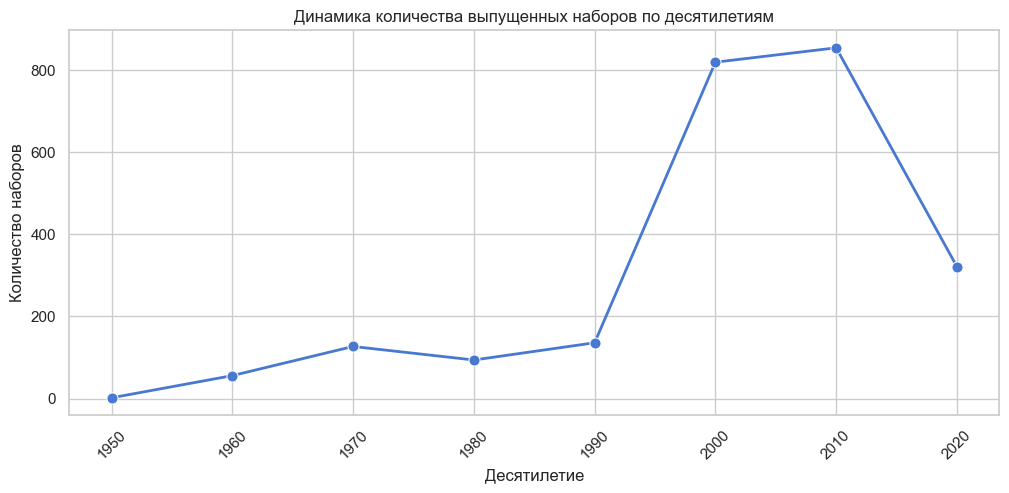


=== 5. Распределение рейтингов качества (Aggregate Rating) ===


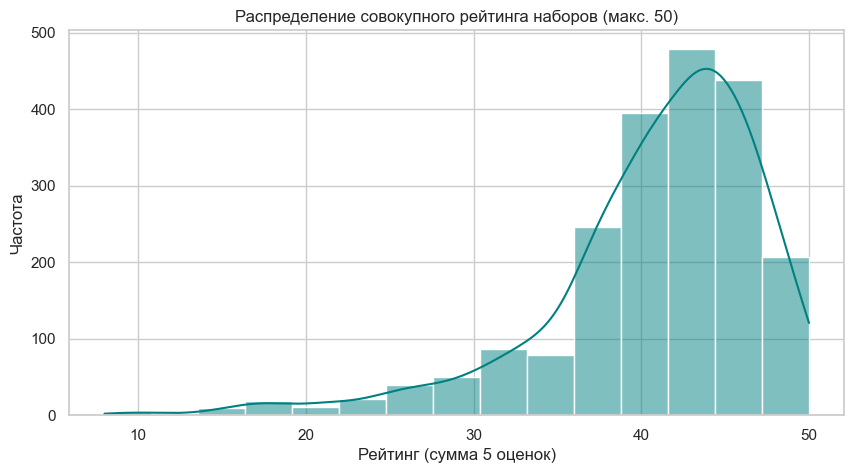


=== 6. Распределение количества фигур в наборе (выбросы) ===


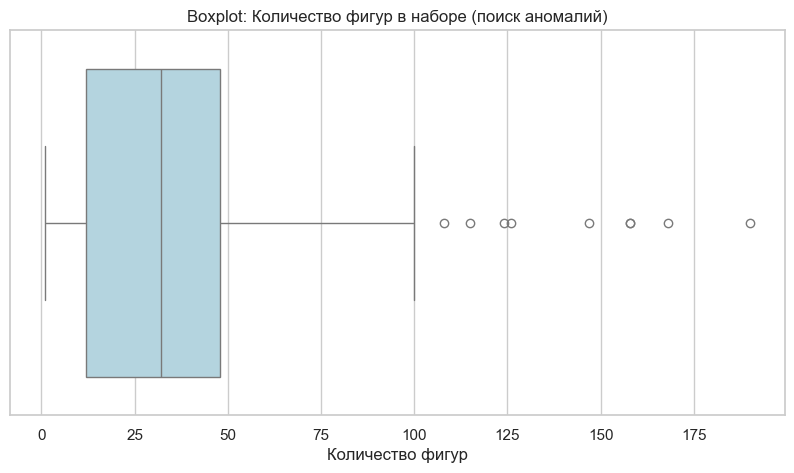


=== 7. Средний рейтинг качества по Топ-10 производителям ===


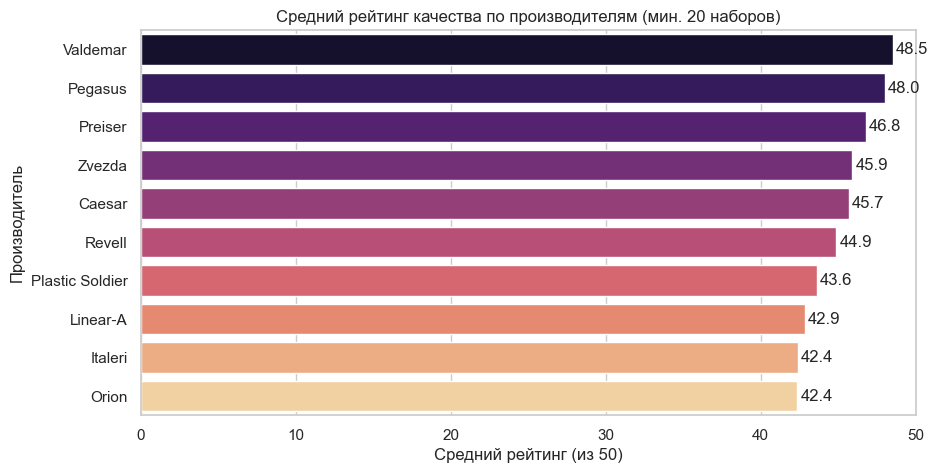

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['Arial'] # Шрифт с поддержкой кириллицы

# ==============================================================================
# 1. ЗАГРУЗКА ДАННЫХ 
# ==============================================================================
df_sets = pd.read_csv('df_sets.csv', dtype={
    'release_year': 'Int64',
    'aggregate_rating': 'Int64',
    'num_figures': 'Int64',
    'decade': 'Int64',
    'years_since_release': 'Int64'
})

df = pd.read_csv('df_consolidated_clean.csv', dtype={
    'release_year': 'Int64',
    'aggregate_rating': 'Int64',
    'num_figures': 'Int64',
    'decade': 'Int64',
    'years_since_release': 'Int64'
})

# ==============================================================================
# 2. РАЗВЕДОЧНЫЙ АНАЛИЗ (EDA)
# ==============================================================================

print("=== 1. Распределение по производителям (Топ-10) ===")
top_manufacturers = df_sets['manufacturer'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, 
            hue=top_manufacturers.index, palette="viridis", legend=False)
plt.title('Топ-10 производителей по количеству наборов')
plt.xlabel('Количество наборов')
plt.ylabel('Производитель')
plt.show()

print("\n=== 2. Распределение по историческим периодам ===")
era_counts = df_sets['era'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(era_counts.values, labels=era_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("pastel"))
plt.title('Доля наборов по историческим эрам')
plt.show()

print("\n=== 3. Распределение по национальностям (Топ-15) ===")
# Фильтруем "Не указано" прямо в value_counts()
top_nationalities = df['nationality'].value_counts()
top_nationalities = top_nationalities[top_nationalities.index != 'Не указано']
print(top_nationalities.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_nationalities.head(15).values, 
    y=top_nationalities.head(15).index,
    hue=top_nationalities.head(15).index, 
    palette="crest", 
    legend=False
)
plt.title('Топ-15 национальностей в наборах (без "Не указано")')
plt.xlabel('Количество упоминаний')
plt.ylabel('Национальность')
plt.tight_layout()
plt.show()

print("\n=== 4. Динамика выпусков по десятилетиям ===")
df_with_year = df_sets[df_sets['release_year'].notna()]
decade_counts = df_with_year['decade'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
sns.lineplot(x=decade_counts.index.astype(str), y=decade_counts.values, 
             marker='o', linewidth=2, markersize=8)
plt.title('Динамика количества выпущенных наборов по десятилетиям')
plt.xlabel('Десятилетие')
plt.ylabel('Количество наборов')
plt.xticks(rotation=45)
plt.show()

print("\n=== 5. Распределение рейтингов качества (Aggregate Rating) ===")
df_with_rating = df_sets[df_sets['aggregate_rating'].notna()]
plt.figure(figsize=(10, 5))
sns.histplot(df_with_rating['aggregate_rating'], bins=15, kde=True, color="teal")
plt.title('Распределение совокупного рейтинга наборов (макс. 50)')
plt.xlabel('Рейтинг (сумма 5 оценок)')
plt.ylabel('Частота')
plt.show()

print("\n=== 6. Распределение количества фигур в наборе (выбросы) ===")
df_with_figures = df_sets[df_sets['num_figures'].notna()]
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_with_figures['num_figures'], color="lightblue")
plt.title('Boxplot: Количество фигур в наборе (поиск аномалий)')
plt.xlabel('Количество фигур')
plt.show()

print("\n=== 7. Средний рейтинг качества по Топ-10 производителям ===")
manufacturer_stats = df_with_rating.groupby('manufacturer').agg(
    avg_rating=('aggregate_rating', 'mean'),
    kit_count=('id', 'count')
).reset_index()

manufacturer_stats = manufacturer_stats[manufacturer_stats['kit_count'] >= 20].sort_values('avg_rating', ascending=False).head(10)

plt.figure(figsize=(10, 5))
# ИСПРАВЛЕНО: добавлены hue и legend=False для barplot с data
sns.barplot(data=manufacturer_stats, x='avg_rating', y='manufacturer', 
            hue='manufacturer', palette="magma", legend=False)
plt.title('Средний рейтинг качества по производителям (мин. 20 наборов)')
plt.xlabel('Средний рейтинг (из 50)')
plt.ylabel('Производитель')

for i, v in enumerate(manufacturer_stats['avg_rating']):
    plt.text(v + 0.2, i, f"{v:.1f}", va='center')
plt.xlim(0, 50)
plt.show()

## Результат шага
Получено первичное визуальное и статистическое понимание структуры данных. 
Выявлены доминирующие категории, общая динамика рынка и подтверждено отсутствие критических аномалий в числовых полях